# Notebook to generate figures for the GSP poster

In [1]:
import pathlib

import pandas as pd

## Loading data

In [2]:
output_folder = pathlib.Path("../../data/outputs_nosync/outputs_leaf/") # Change this for different outputs
prediction_runs = [fol for fol in output_folder.iterdir() if fol.is_dir()]
prediction_runs

[PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_mutual_info_1000'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_pca_200'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_chi2_1000'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_nmf_200'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_f_1000')]

In [3]:
def read_csv_files(folder_list: list[pathlib.Path], file_name: str, reindex: bool = True):
    df_list = []
    for folder in folder_list:
        file_path = folder / file_name
        df = pd.read_csv(file_path, index_col=0)
        df_list.append(df)
    df_concat = pd.concat(df_list)
    if reindex:
        df_concat.index = list(range(df_concat.shape[0])) # type: ignore
    return df_concat

In [4]:
scores_df = read_csv_files(prediction_runs, "all_feat_scores_data.csv", reindex=True)
scores_df

,name,category,accuracy,balanced_accuracy,f1,precision,recall,matthews_corrcoef,class_0,class_1,feature,run_id
0,Oxalate,leaf_biolog,0.983333,0.990741,0.923077,0.857143,1.000000,0.917208,181,19,cluster30,biolog_mutual_info_1000
1,Mannitol,leaf_biolog,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,111,92,cluster30,biolog_mutual_info_1000
2,Pyruvate,leaf_biolog,0.866667,0.820513,0.904762,0.844444,0.974359,0.706099,69,128,cluster30,biolog_mutual_info_1000
3,Succite,leaf_biolog,0.967213,0.955797,0.978261,0.978261,0.978261,0.911594,48,153,cluster30,biolog_mutual_info_1000
4,Histidine,leaf_biolog,0.967213,0.933333,0.928571,1.000000,0.866667,0.911348,151,51,cluster30,biolog_mutual_info_1000
...,...,...,...,...,...,...,...,...,...,...,...,...
2875,Sucrose,leaf_biolog,0.862069,0.820155,0.906977,0.906977,0.906977,0.640310,51,142,uniref90,biolog_f_1000
2876,Leucine,leaf_biolog,0.915254,0.772727,0.705882,1.000000,0.545455,0.702849,158,38,uniref90,biolog_f_1000
2877,Tyrosine,leaf_biolog,0.915254,0.861111,0.838710,1.000000,0.722222,0.802322,135,59,uniref90,biolog_f_1000
2878,Maltose,leaf_biolog,0.933333,0.913043,0.948718,0.902439,1.000000,0.863419,74,123,uniref90,biolog_f_1000


In [5]:
cv_scores_df = read_csv_files(prediction_runs, "all_feat_cv_scores_data.csv", reindex=True)
cv_scores_df

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,matthews_corrcoef,name,category,fold_num,feature,run_id
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Oxalate,leaf_biolog,1,cluster30,biolog_mutual_info_1000
1,0.950000,0.972222,0.666667,1.000000,0.800000,0.958333,0.793492,Oxalate,leaf_biolog,2,cluster30,biolog_mutual_info_1000
2,0.950000,0.861111,0.750000,0.750000,0.750000,0.972222,0.722222,Oxalate,leaf_biolog,3,cluster30,biolog_mutual_info_1000
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Oxalate,leaf_biolog,4,cluster30,biolog_mutual_info_1000
4,0.975000,0.875000,1.000000,0.750000,0.857143,1.000000,0.854242,Oxalate,leaf_biolog,5,cluster30,biolog_mutual_info_1000
...,...,...,...,...,...,...,...,...,...,...,...,...
14395,0.875000,0.772727,1.000000,0.545455,0.705882,0.962382,0.682086,myo_inositol,leaf_biolog,1,uniref90,biolog_f_1000
14396,0.825000,0.732143,0.857143,0.500000,0.631579,0.922619,0.559950,myo_inositol,leaf_biolog,2,uniref90,biolog_f_1000
14397,0.800000,0.738095,0.700000,0.583333,0.636364,0.901786,0.503953,myo_inositol,leaf_biolog,3,uniref90,biolog_f_1000
14398,0.871795,0.772727,1.000000,0.545455,0.705882,0.944805,0.680301,myo_inositol,leaf_biolog,4,uniref90,biolog_f_1000


In [6]:
score_columns = ["balanced_accuracy", "matthews_corrcoef", "accuracy",  "f1", "precision", "recall", "roc_auc" ]

## Overall performance of the different feature representations

Which feature representation has the overall best performance?

In [7]:
cols = ["feature"] + score_columns
(
    cv_scores_df
    .loc[cv_scores_df.run_id == "biolog_chi2_1000", cols]
    .groupby("feature")
    .mean()
    .sort_values("balanced_accuracy", ascending=False)
)

,balanced_accuracy,matthews_corrcoef,accuracy,f1,precision,recall,roc_auc
feature,,,,,,,
eggnog_kegg,0.867026,0.766716,0.920265,0.846985,0.885360,0.834555,0.958047
kofam,0.864255,0.760375,0.918395,0.844421,0.877044,0.832489,0.957230
cluster30,0.858712,0.759078,0.917692,0.847503,0.890044,0.827068,0.960386
cluster50,0.855146,0.756217,0.916870,0.845002,0.892760,0.821431,0.959807
cluster70,0.842158,0.729501,0.907722,0.827344,0.877011,0.808709,0.954405
kofam_modules,0.839959,0.721199,0.901791,0.821007,0.865324,0.810288,0.941223
uniref30,0.838511,0.734924,0.910599,0.834616,0.893159,0.809360,0.951468
rast,0.830193,0.702236,0.903272,0.796924,0.852502,0.779753,0.942782
cluster90,0.803141,0.663619,0.888442,0.775674,0.848071,0.748497,0.929917


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
def group_feature(feature: str) -> str:
    denovo_features = [
        "cluster30",
        "cluster50",
        "cluster70",
        "cluster90",
    ]
    metabolic_features = [
        "eggnog_kegg",
        "eggnog_seed",
        "kofam",
        "kofam_modules",
        "rast",
    ]
    protein_features = [
        "uniprot_trembl",
        "uniref30",
        "uniref50",
        "uniref70",
        "uniref90",
    ]
    if feature in metabolic_features:
        return "Metabolic"
    elif feature in protein_features:
        return "Protein"
    elif feature in denovo_features:
        return "De novo"
    else:
        raise ValueError(f"Feature {feature} not found in any group")

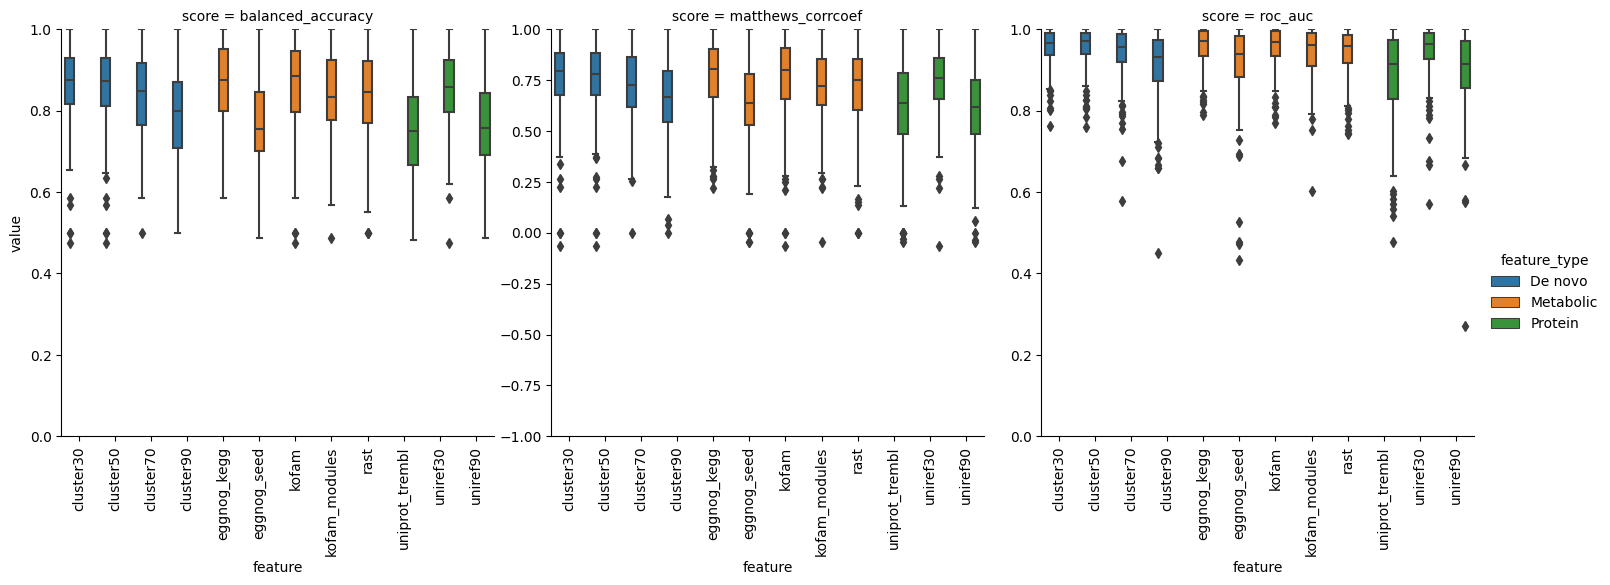

In [10]:
# Use full data for the plot
cols = score_columns + ["feature"]
plot_data = (
    cv_scores_df
    .loc[cv_scores_df.run_id == "biolog_mutual_info_1000", cols]
    .melt(id_vars="feature", value_vars=score_columns, var_name="score", value_name="value")
)
plot_data = plot_data[plot_data.score.isin(["balanced_accuracy", "matthews_corrcoef", "roc_auc"])]
plot_data["feature_type"] = plot_data.feature.apply(group_feature)
g = sns.catplot(data=plot_data, x="feature", y="value", col="score", hue="feature_type", kind="box", col_wrap=3, sharey=False, sharex=True)
for i, ax in enumerate(g.axes.flat):
    ax.tick_params(axis='x', rotation=90, which="both");
    if i == 1:
        ax.set_ylim(-1, 1)
    else:
        ax.set_ylim(0, 1)

## Overall performance of the different feature selection/reduction methods

Which feature selection/reduction method has the overall best performance?

In [11]:
cols = ["run_id"] + score_columns
(
    cv_scores_df
    # .loc[cv_scores_df.feature == "eggnog_kegg", cols]
    .loc[cv_scores_df.feature == "rast", cols]
    .groupby("run_id")
    .mean()
    .sort_values("balanced_accuracy", ascending=False)
)

,balanced_accuracy,matthews_corrcoef,accuracy,f1,precision,recall,roc_auc
run_id,,,,,,,
biolog_mutual_info_1000,0.833906,0.706849,0.902966,0.803942,0.856446,0.787726,0.939851
biolog_f_1000,0.832066,0.710191,0.904422,0.802964,0.866445,0.779980,0.943579
biolog_chi2_1000,0.830193,0.702236,0.903272,0.796924,0.852502,0.779753,0.942782
biolog,0.810516,0.667198,0.893228,0.770464,0.831722,0.750890,0.925280
biolog_pca_200,0.696195,0.477607,0.848543,0.609614,0.717655,0.592791,0.880852
biolog_nmf_200,0.635109,0.346351,0.805745,0.551285,0.653212,0.543976,0.802586


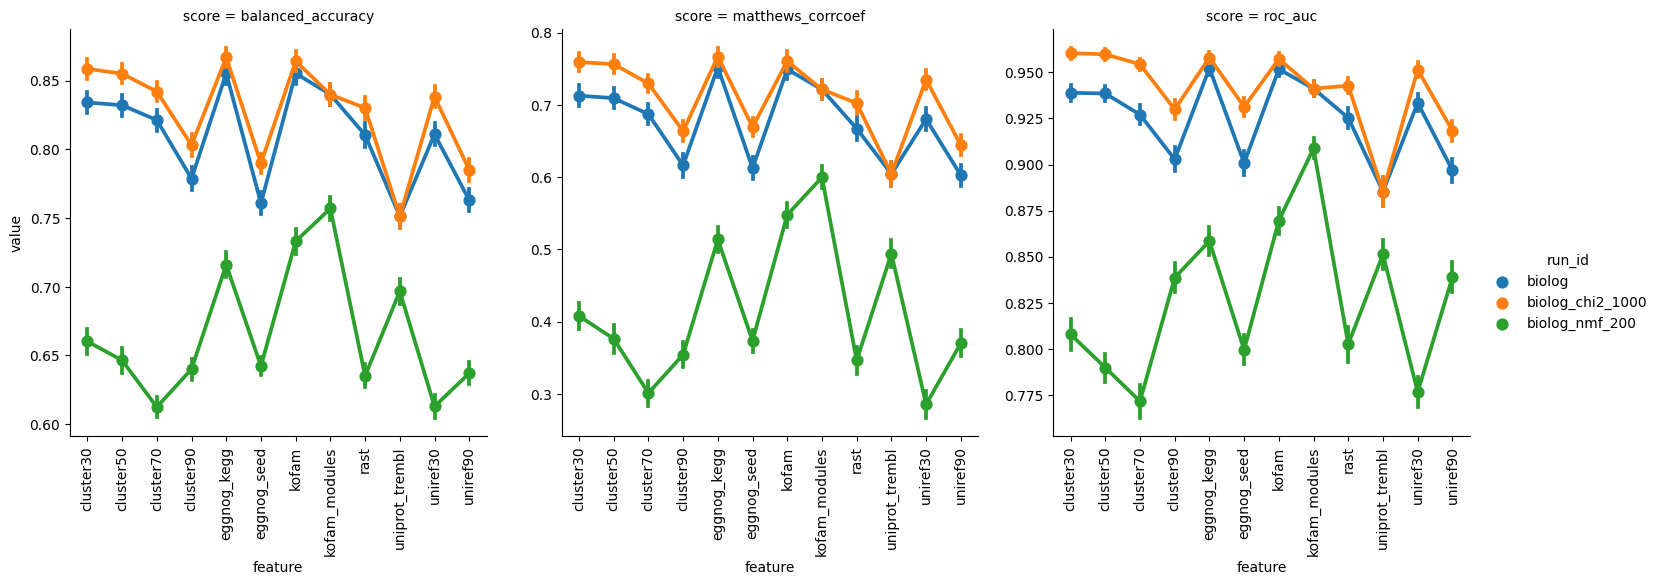

In [12]:
cols = score_columns
plot_data = (
    cv_scores_df
    .loc[cv_scores_df.run_id.isin(["biolog", "biolog_chi2_1000", "biolog_nmf_200"]), :]
    .melt(id_vars=["run_id", "feature"], value_vars=score_columns, var_name="score", value_name="value")
)
plot_data = plot_data[plot_data.score.isin(["balanced_accuracy", "matthews_corrcoef", "roc_auc"])]
plot_data["feature_type"] = plot_data.feature.apply(group_feature)

g = sns.catplot(data=plot_data, x="feature", y="value", errorbar="se", kind="point", col="score", sharey=False, col_wrap=3, hue="run_id")
for i, ax in enumerate(g.axes.flat):
    ax.tick_params(axis='x', rotation=90, which="both");
    # if i == 1:
    #     ax.set_ylim(-1, 1)
    # else:
    #     ax.set_ylim(0, 1)

## Overall predictive capability of each phenotype model

Which phenotype model has the best prediction performance?

In [13]:
cols = ["name"] + score_columns
top_phenotypes = (
    cv_scores_df
    .loc[cv_scores_df.run_id == "biolog_chi2_1000", cols]
    .groupby("name")
    .mean()
    .sort_values("balanced_accuracy", ascending=False)
)
top_phenotypes.head(20)

,balanced_accuracy,matthews_corrcoef,accuracy,f1,precision,recall,roc_auc
name,,,,,,,
Methanol_La3,0.969155,0.951235,0.985828,0.954890,0.980655,0.942857,0.994814
Formate,0.955179,0.944496,0.987620,0.947476,0.996667,0.910833,0.988395
Oxalate,0.930317,0.858550,0.972533,0.863810,0.882222,0.877778,0.982216
Mannitol,0.913964,0.834008,0.913740,0.903160,0.908971,0.910026,0.970158
Maltose,0.910150,0.836948,0.920419,0.937062,0.925793,0.953639,0.979670
Cellobiose,0.886759,0.807438,0.911791,0.935946,0.905561,0.972092,0.960543
Glucose,0.878607,0.811394,0.943063,0.965567,0.946744,0.986381,0.957441
Histidine,0.864606,0.772351,0.916105,0.805002,0.907875,0.758493,0.973938
Trehalose,0.861592,0.767196,0.893502,0.922840,0.885384,0.967217,0.951121


The performance of different feature representations on phenotypes

In [14]:
scores_df

,name,category,accuracy,balanced_accuracy,f1,precision,recall,matthews_corrcoef,class_0,class_1,feature,run_id
0,Oxalate,leaf_biolog,0.983333,0.990741,0.923077,0.857143,1.000000,0.917208,181,19,cluster30,biolog_mutual_info_1000
1,Mannitol,leaf_biolog,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,111,92,cluster30,biolog_mutual_info_1000
2,Pyruvate,leaf_biolog,0.866667,0.820513,0.904762,0.844444,0.974359,0.706099,69,128,cluster30,biolog_mutual_info_1000
3,Succite,leaf_biolog,0.967213,0.955797,0.978261,0.978261,0.978261,0.911594,48,153,cluster30,biolog_mutual_info_1000
4,Histidine,leaf_biolog,0.967213,0.933333,0.928571,1.000000,0.866667,0.911348,151,51,cluster30,biolog_mutual_info_1000
...,...,...,...,...,...,...,...,...,...,...,...,...
2875,Sucrose,leaf_biolog,0.862069,0.820155,0.906977,0.906977,0.906977,0.640310,51,142,uniref90,biolog_f_1000
2876,Leucine,leaf_biolog,0.915254,0.772727,0.705882,1.000000,0.545455,0.702849,158,38,uniref90,biolog_f_1000
2877,Tyrosine,leaf_biolog,0.915254,0.861111,0.838710,1.000000,0.722222,0.802322,135,59,uniref90,biolog_f_1000
2878,Maltose,leaf_biolog,0.933333,0.913043,0.948718,0.902439,1.000000,0.863419,74,123,uniref90,biolog_f_1000


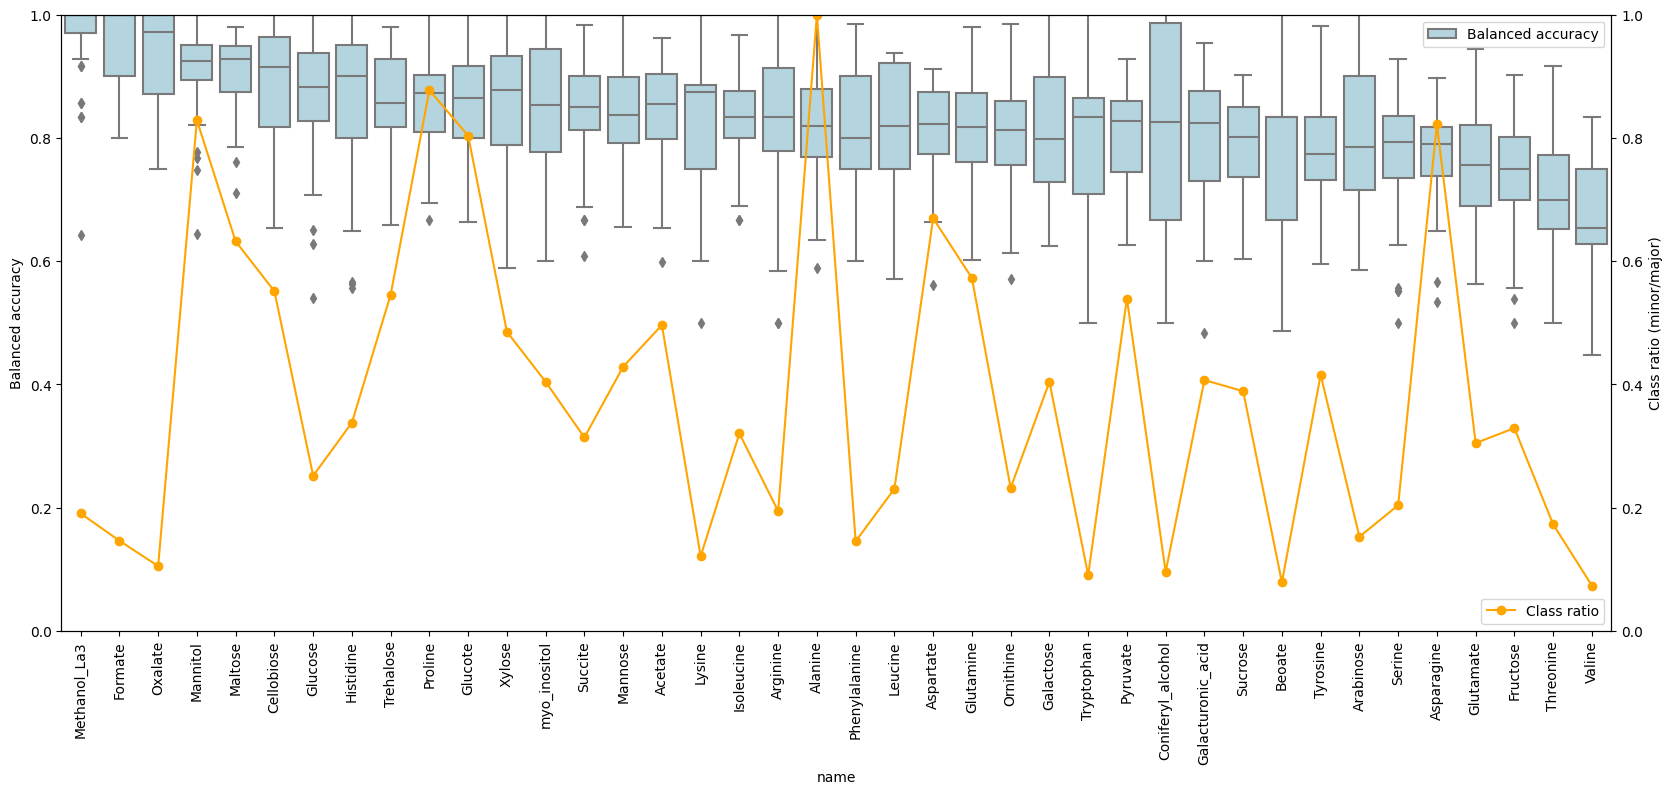

In [15]:
cols = score_columns
plot_data = (
    cv_scores_df
    .loc[cv_scores_df.run_id == "biolog_chi2_1000", :]
    .melt(id_vars=["name", "feature"], value_vars=score_columns, var_name="score", value_name="value")
)
plot_data = plot_data[plot_data.score.isin(["balanced_accuracy"])]
plot_data["feature_type"] = plot_data.feature.apply(group_feature)
order = list(top_phenotypes.index)
class_ratio = (
    scores_df
    .groupby("name")
    .first()
    .apply(lambda x: min(x.class_0, x.class_1) / max(x.class_0, x.class_1), axis=1)
    .loc[order]
)

fig, ax1 = plt.subplots(figsize=(20, 8))
ax2 = ax1.twinx()
g = sns.boxplot(data=plot_data, x="name", y="value", color="lightblue", order=order, ax=ax1)
labels = ["Balanced accuracy"]
ax1.legend(labels=labels)
ax1.set_ylim(0, 1)
ax1.set_ylabel("Balanced accuracy")
ax1.tick_params(axis='x', rotation=90, which="both");
ax2.plot(order, class_ratio, 'o-', color="orange", label="Class ratio")
ax2.set_ylim(0, 1)
ax2.set_ylabel("Class ratio (minor/major)");
plt.legend(loc="lower right");

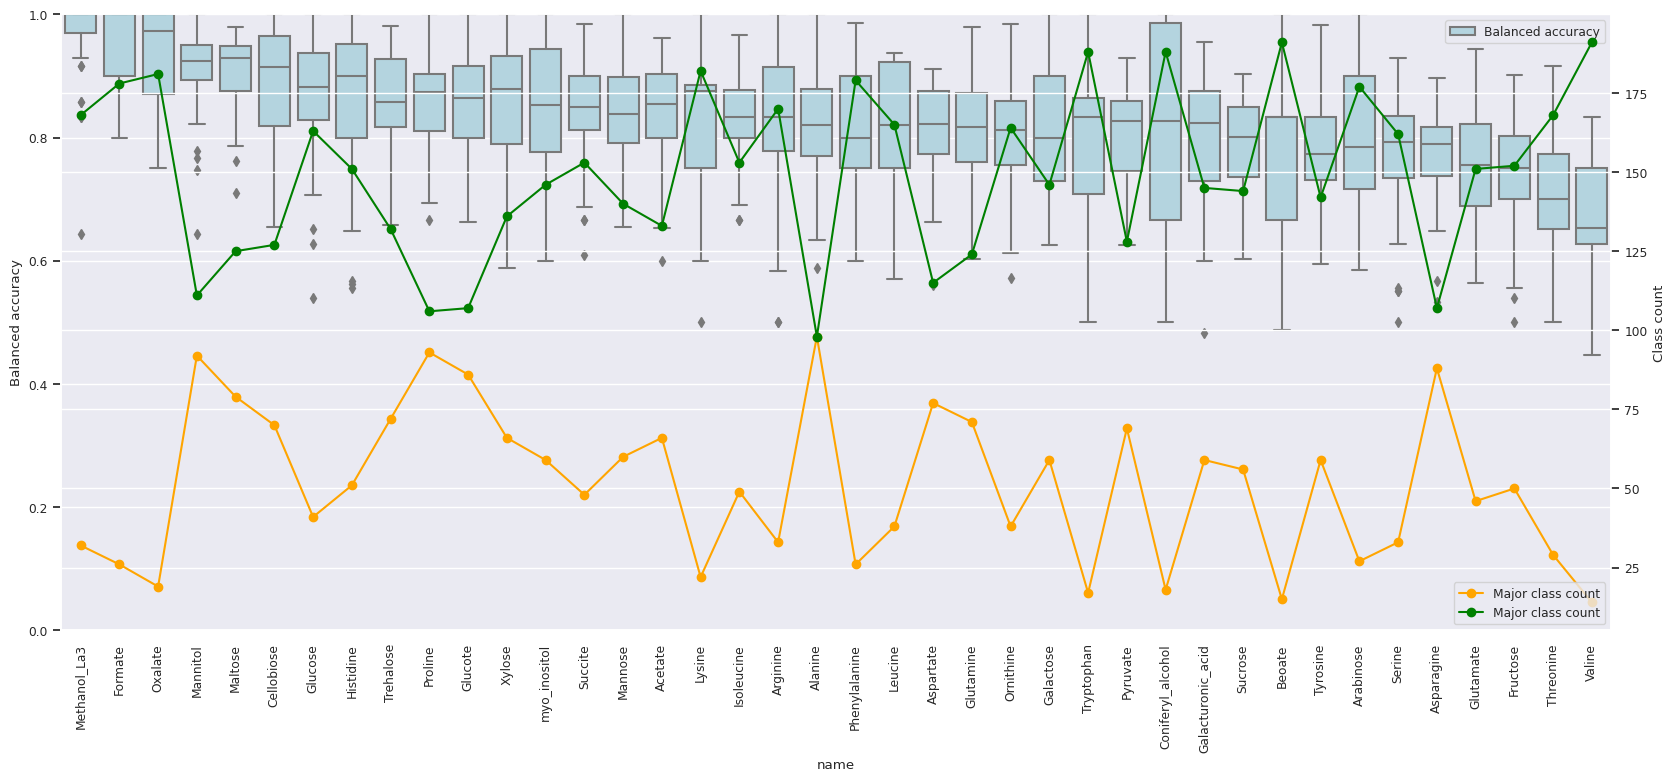

In [19]:
cols = score_columns
plot_data = (
    cv_scores_df
    .loc[cv_scores_df.run_id == "biolog_chi2_1000", :]
    .melt(id_vars=["name", "feature"], value_vars=score_columns, var_name="score", value_name="value")
)
plot_data = plot_data[plot_data.score.isin(["balanced_accuracy"])]
plot_data["feature_type"] = plot_data.feature.apply(group_feature)
order = list(top_phenotypes.index)
major_class = (
    scores_df
    .groupby("name")
    .first()
    .apply(lambda x: max(x.class_0, x.class_1), axis=1)
    .loc[order]
)
minor_class = (
    scores_df
    .groupby("name")
    .first()
    .apply(lambda x: min(x.class_0, x.class_1), axis=1)
    .loc[order]
)

fig, ax1 = plt.subplots(figsize=(20, 8))
ax2 = ax1.twinx()
g = sns.boxplot(data=plot_data, x="name", y="value", color="lightblue", order=order, ax=ax1)
labels = ["Balanced accuracy"]
ax1.legend(labels=labels)
ax1.set_ylim(0, 1)
ax1.set_ylabel("Balanced accuracy")
ax1.tick_params(axis='x', rotation=90, which="both");
ax2.plot(order, minor_class, 'o-', color="orange", label="Major class count")
ax2.plot(order, major_class, 'o-', color="green", label="Major class count")
# ax2.set_ylim(0, 1)
ax2.set_ylabel("Class count");
plt.legend(loc="lower right");

## Phenotype prediction vs. feature representation

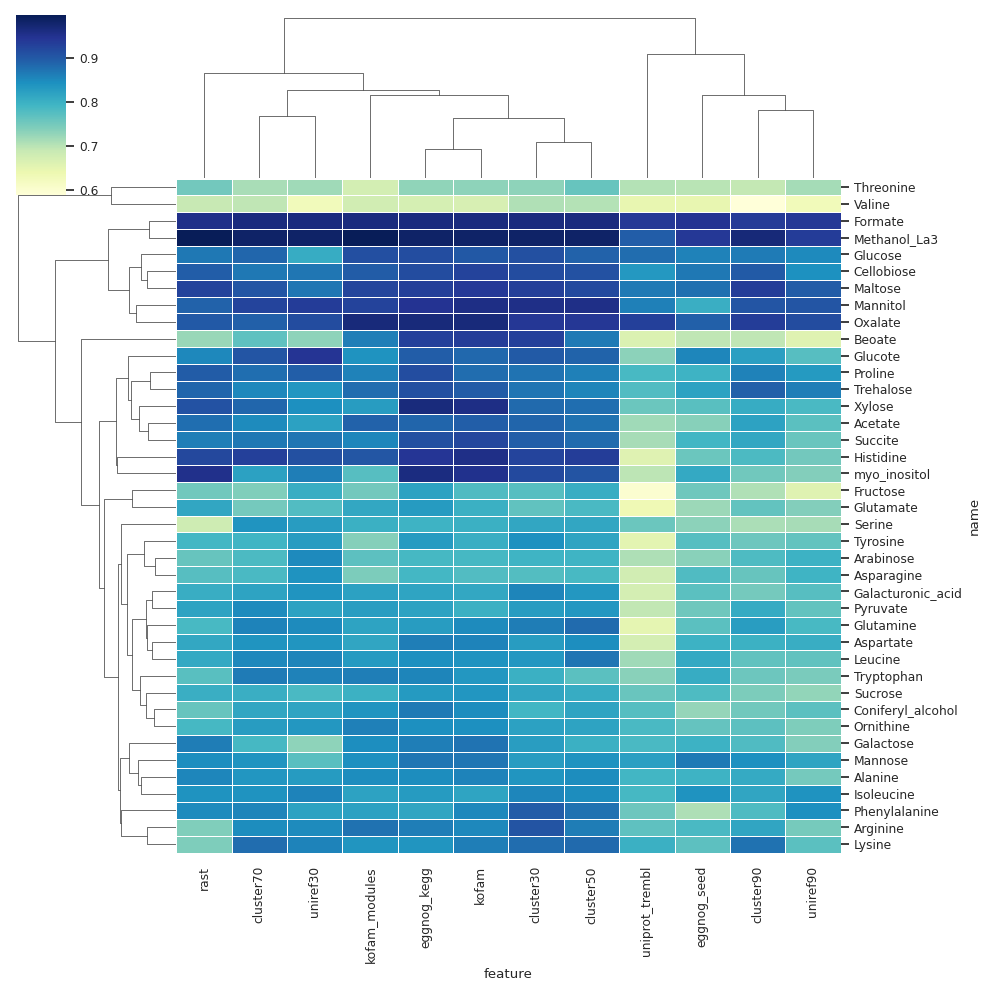

In [16]:
plot_data = (
    cv_scores_df
    .loc[cv_scores_df.run_id == "biolog_chi2_1000", ["feature", "name", "balanced_accuracy"]]
    .groupby(by=["feature", "name"])
    .mean()
    .reset_index()
    .sort_values(by="balanced_accuracy", ascending=False)
    .pivot(index="name", columns="feature", values="balanced_accuracy")
)
sns.set_theme(font_scale=0.8)
sns.clustermap(plot_data,  linewidths=.5, cmap="YlGnBu", yticklabels=1)

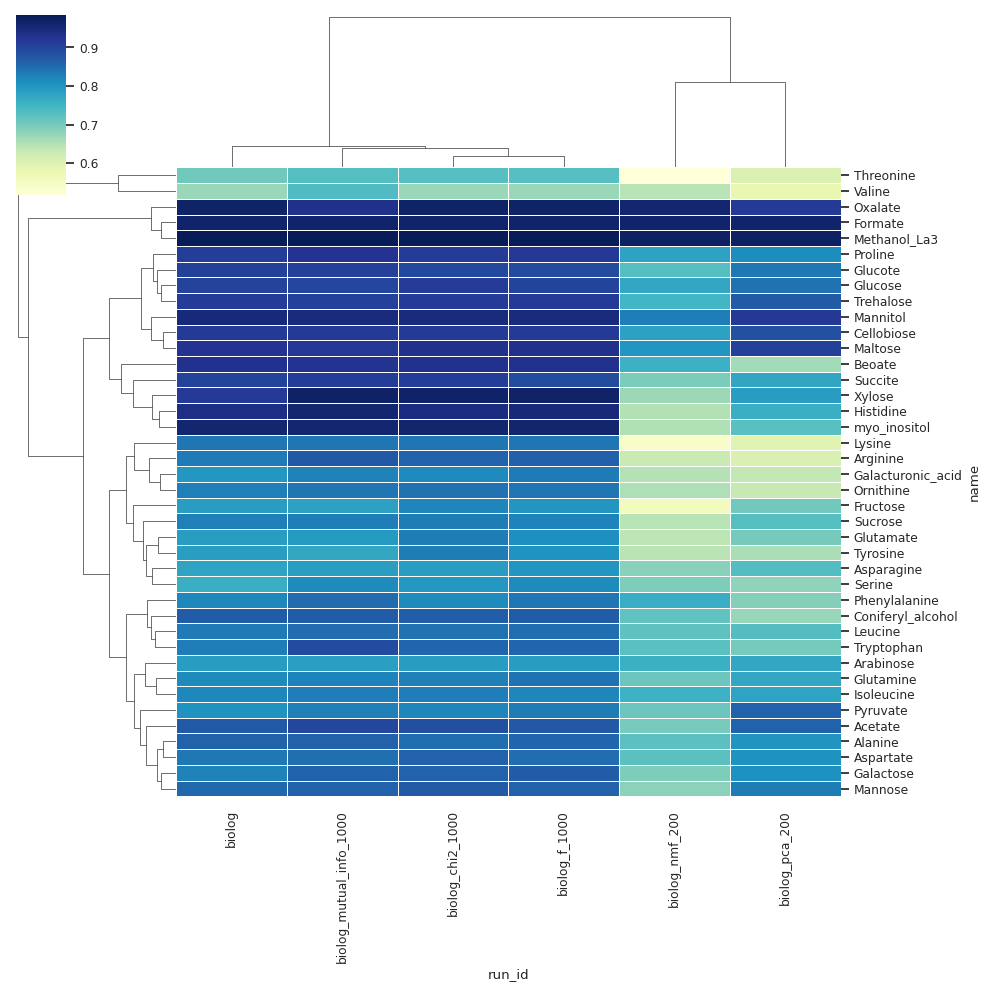

In [17]:
plot_data = (
    cv_scores_df
    .loc[cv_scores_df.feature == "eggnog_kegg", ["run_id", "name", "balanced_accuracy"]]
    .groupby(by=["run_id", "name"])
    .mean()
    .reset_index()
    .sort_values(by="balanced_accuracy", ascending=False)
    .pivot(index="name", columns="run_id", values="balanced_accuracy")
)
sns.set_theme(font_scale=0.8)
sns.clustermap(plot_data,  linewidths=.5, cmap="YlGnBu", yticklabels=1)